# Downloading the dataset.

In [2]:
!pip install -q kaggle
from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle config view

!kaggle datasets download -d bulentsiyah/semantic-drone-dataset

import zipfile
import os

zip_file = [f for f in os.listdir() if f.startswith('semantic-drone-dataset') and f.endswith('.zip')][0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('drone_dataset')

print("Dataset downloaded and extracted successfully!")

Saving kaggle.json to kaggle.json
Configuration values from /root/.kaggle
- username: tunyminn
- path: None
- proxy: None
- competition: None
Dataset URL: https://www.kaggle.com/datasets/bulentsiyah/semantic-drone-dataset
License(s): other
100% 3.88G/3.89G [00:50<00:00, 274MB/s]
100% 3.89G/3.89G [00:50<00:00, 82.9MB/s]
Dataset downloaded and extracted successfully!


# Load Libraries and necessary libraries

In [3]:
!pip install -q segmentation-models-pytorch
!pip install -q torchsummary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision
import torch.nn.functional as F
from torch.autograd import Variable

from PIL import Image
import cv2
import albumentations as A

import time
from tqdm.notebook import tqdm

from torchsummary import summary
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
IMAGE_PATH = '/content/drone_dataset/dataset/semantic_drone_dataset/original_images/'
MASK_PATH = '/content/drone_dataset/dataset/semantic_drone_dataset/label_images_semantic/'
n_classes = 23

There are total of 23 classees apart from the unlabelled one. They are presented with unique color value.

As for the Safe Landing zone segmentation, we will only need to check at the dirt, grass and rocks. These classes will be used as an indicator for the safe landing zone.

| Class ID | RGB Values      | Class Label | Color Name (Approximate)    |
| -------- | --------------- | ----------- | --------------------------- |
| 0        | (0, 0, 0)       | unlabeled   | Black                       |
| 1        | (128, 64, 128)  | paved-area  | Purple (Amethyst)           |
| 2        | (130, 76, 0)    | dirt        | Brown (Dark Bronze)         |
| 3        | (0, 102, 0)     | grass       | Forest Green                |
| 4        | (112, 103, 87)  | gravel      | Taupe / Driftwood           |
| 5        | (28, 42, 168)   | water       | Royal Blue                  |
| 6        | (48, 41, 30)    | rocks       | Dark Olive / Charcoal Brown |
| 7        | (0, 50, 89)     | pool        | Navy Blue                   |
| 8        | (107, 142, 35)  | vegetation  | Olive Drab                  |
| 9        | (70, 70, 70)    | roof        | Dim Gray                    |
| 10       | (102, 102, 156) | wall        | Slate Blue                  |
| 11       | (254, 228, 12)  | window      | Gold / Banana Yellow        |
| 12       | (254, 148, 12)  | door        | Orange / Safety Orange      |
| 13       | (190, 153, 153) | fence       | Rosy Brown                  |
| 14       | (153, 153, 153) | fence-pole  | Gray                        |
| 15       | (255, 22, 96)   | person      | Bright Pink / Raspberry Red |
| 16       | (102, 51, 0)    | dog         | Saddle Brown                |
| 17       | (9, 143, 150)   | car         | Teal / Sea Green            |
| 18       | (119, 11, 32)   | bicycle     | Crimson / Dark Red          |
| 19       | (51, 51, 0)     | tree        | Olive / Dark Khaki          |
| 20       | (190, 250, 190) | bald-tree   | Light Mint / Pale Green     |
| 21       | (112, 150, 146) | ar-marker   | Slate Green                 |
| 22       | (2, 135, 115)   | obstacle    | Sea Green / Tropical Teal   |
| 23       | (255, 0, 0)     | conflicting | Bright Red                  |


# Data Splitting

In [6]:
def create_dataframe():
    image_ids = []
    for _, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            if filename.endswith('.jpg'):
                image_ids.append(filename.split('.')[0])
    return pd.DataFrame({'id': image_ids})

df = create_dataframe()
print(f'Total Images: {len(df)}')

Total Images: 400


There are total of 400 images in the dataset. The data will be splitted into 15% validation and 10% testing.

In [7]:
def split_data(df, test_size=0.1, val_size=0.15, random_state=19):
    train_val, test = train_test_split(df['id'].values, test_size=test_size, random_state=random_state)
    train, val = train_test_split(train_val, test_size=val_size, random_state=random_state)
    return train, val, test

X_train, X_val, X_test = split_data(df)
print(f'Train Size: {len(X_train)}')
print(f'Val Size: {len(X_val)}')
print(f'Test Size: {len(X_test)}')

Train Size: 306
Val Size: 54
Test Size: 40


In [8]:
img = Image.open(IMAGE_PATH + df['id'][17] + '.jpg')
mask = Image.open(MASK_PATH + df['id'][17] + '.png')
print('Image Size', np.asarray(img).shape)
print('Mask Size', np.asarray(mask).shape)

Image Size (4000, 6000, 3)
Mask Size (4000, 6000)


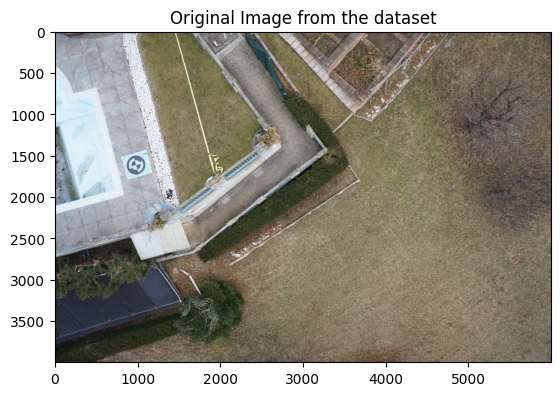

In [9]:
plt.imshow(img)
plt.title('Original Image from the dataset')
plt.show()

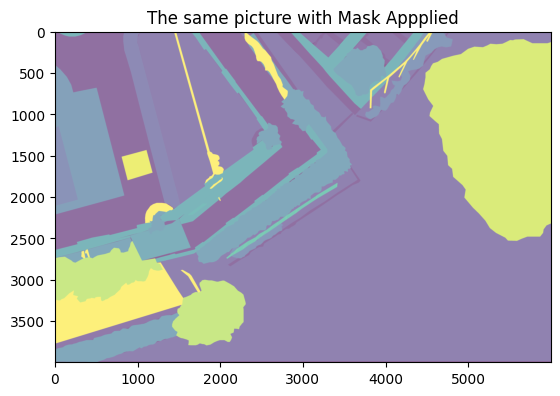

In [10]:
plt.imshow(mask, alpha = 0.6)
plt.title('The same picture with Mask Appplied')
plt.show()

# Data Preprocessing

1. Training Preprocessing:

During training, the input images and masks goes through a series of transformations to enhance model generalization and robustness. Firstly, images are normalized using ImageNet mean and standard deviation values. Then resized to a fixed resolution (704×1056 pixels) to ensure consistent dimensions, with masks using nearest-neighbor sampling. This preserves label accuracy. Moreover, augmentations such as random horizontal and vertical flips, grid distortion, brightness-contrast adjustments, and Gaussian noise are applied to introduce variability and prevent overfitting.

2. Testing Preprocessing:

Images are normalized using the same ImageNet structure as training. They are resized to the target resolution (768×1152 pixels) without any augmentations. Masks are similarly resized using nearest-neighbor interpolation.

In [11]:
class DroneDataset(Dataset):
    def __init__(self, img_path, mask_path, X, mean, std, transform=None, patch=False):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.transform = transform
        self.patches = patch
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_path + self.X[idx] + '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_path + self.X[idx] + '.png', cv2.IMREAD_GRAYSCALE)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = Image.fromarray(aug['image'])
            mask = aug['mask']
        else:
            img = Image.fromarray(img)

        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        img = t(img)
        mask = torch.from_numpy(mask).long()

        if self.patches:
            img, mask = self._create_patches(img, mask)

        return img, mask

    def _create_patches(self, img, mask):
        img_patches = img.unfold(1, 512, 512).unfold(2, 768, 768)
        img_patches = img_patches.contiguous().view(3, -1, 512, 768)
        img_patches = img_patches.permute(1, 0, 2, 3)

        mask_patches = mask.unfold(0, 512, 512).unfold(1, 768, 768)
        mask_patches = mask_patches.contiguous().view(-1, 512, 768)

        return img_patches, mask_patches

In [12]:
class DroneTestDataset(Dataset):
    def __init__(self, img_path, mask_path, X, transform=None):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_path + self.X[idx] + '.jpg')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_path + self.X[idx] + '.png', cv2.IMREAD_GRAYSCALE)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = Image.fromarray(aug['image'])
            mask = aug['mask']
        else:
            img = Image.fromarray(img)

        mask = torch.from_numpy(mask).long()
        return img, mask

test_transform = A.Resize(768, 1152, interpolation=cv2.INTER_NEAREST)
test_set = DroneTestDataset(IMAGE_PATH, MASK_PATH, X_test, test_transform)

In [13]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(704, 1056, interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.GridDistortion(p=0.2),
    A.RandomBrightnessContrast((0, 0.5), (0, 0.5)),
    A.GaussNoise()
])

val_transform = A.Compose([
    A.Resize(704, 1056, interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(),
    A.GridDistortion(p=0.2)
])

train_set = DroneDataset(IMAGE_PATH, MASK_PATH, X_train, mean, std, train_transform)
val_set = DroneDataset(IMAGE_PATH, MASK_PATH, X_val, mean, std, val_transform)

batch_size = 3
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=True)

# Model Setup

  
  As part of the project, I have applited 2 models.
  1. UNet with MobileNet V2 Encoder
  2. UNet with ResNet34 Encoder


### **1. UNet Architecture with MobileNet Encoder**

  The first name of the model is UNet. This is the model with MobileNetV2 encoder and is powerful for segmentation. The encoder (MobileNetV2) efficiently downsamples the input by applying the inverted residual blocks with depthwise convolutions. This extracts hierarchical features while reducing spatial dimensions. The decoder also upsamples these features by combining them with skip connections from the encoder to recover fine details. Finally, a segmentation head produces a 23-channel output (one per class) at the original resolution.

The model balances speed (via MobileNet) and precision (via UNet’s structure). This is good for the current drone image segmentation for safe landing zone.

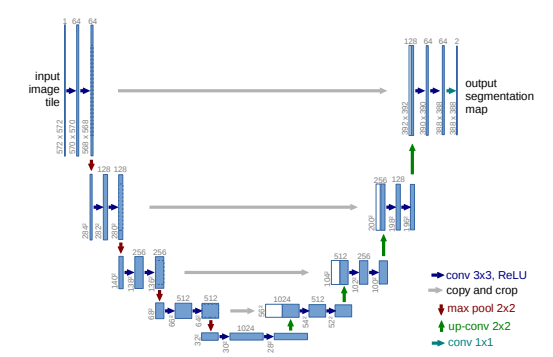

### **2. UNet Architecture with ResNet34 Encoder**


ResNet34 encoder uses residual blocks (3×3 convs with skip connections) to extract features at four scales (64 to 512 channels). This downsamples the input for segmentation. The UNet decoder upsamples these features by merging them with skip connections from corresponding encoder layers via channel-wise concatenation. This particular method refines spatial accuracy. At the end, a final 1×1 conv outputs 23-class logits for pixel-wise prediction. Compared to MobileNetV2 UNet, ResNet34 provides higher accuracy (21M params) but requires more computation.

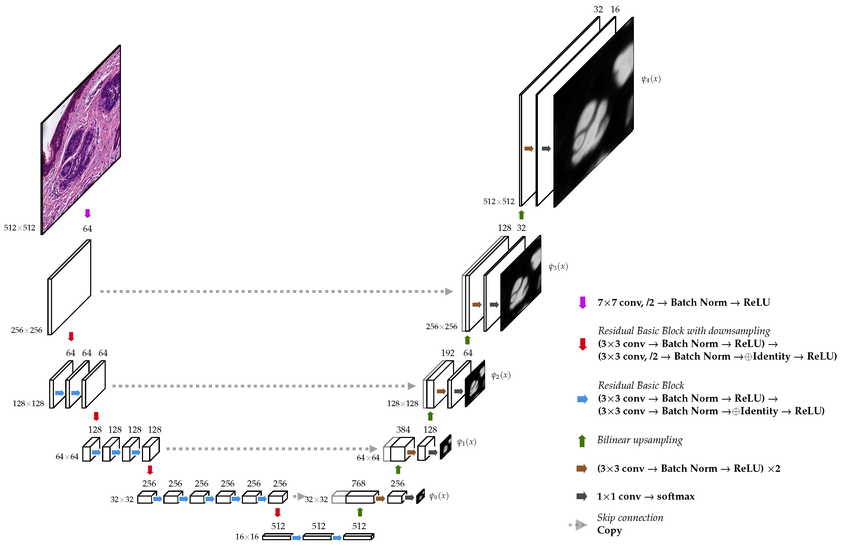

In [14]:

model = smp.Unet(
    encoder_name='mobilenet_v2',
    encoder_weights='imagenet',
    classes=n_classes,
    activation=None,
    encoder_depth=5,
    decoder_channels=[256, 128, 64, 32, 16]
)

model1 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=n_classes,
    activation=None,
    encoder_depth=5,
    decoder_channels=[256, 128, 64, 32, 16]
)

model = model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

## Initializing the Evaluation Metrics

For this task, we will be using 2 evaluation metrics.

1. Calculating the Pixel Accuracy

Pixel accuracy measures the percentage of correctly classified pixels in the segmentation output. Firstly, it converts the model's logits (output) into class predictions by applying softmax (to get probabilities) followed by argmax (to select the most likely class). These predictions are then compared directly to the ground truth mask, counting how many pixels match exactly. The ratio of correct predictions to total pixels gives the accuracy.


2. mIoU (Mean Intersection over Union)

mIoU measures the overlap between predicted and ground truth regions for each class. For each class, it calculates the Intersection-over-Union (IoU), the area of overlap between prediction and ground truth divided by their combined area with a small smoothing term (smooth=1e-10) prevents division by zero.

In [15]:
def calculate_pixel_accuracy(output, mask):
    with torch.no_grad():
        pred = output.softmax(dim=1).argmax(dim=1)
        correct = (pred == mask).float()
        accuracy = correct.sum() / correct.numel()
    return accuracy.item()

def calculate_miou(pred_mask, mask, smooth=1e-10, n_classes=23):
    with torch.no_grad():
        pred_mask = pred_mask.softmax(dim=1).argmax(dim=1)

        pred_flat = pred_mask.view(-1)
        mask_flat = mask.view(-1)

        iou_per_class = []

        for class_id in range(n_classes):
            pred_class = (pred_flat == class_id)
            true_class = (mask_flat == class_id)

            if true_class.sum() == 0:
                iou_per_class.append(float('nan'))
                continue

            intersection = (pred_class & true_class).float().sum()
            union = (pred_class | true_class).float().sum()

            iou = (intersection + smooth) / (union + smooth)
            iou_per_class.append(iou.item())
    return np.nanmean(iou_per_class)

In [16]:
def train_model(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler):
    torch.cuda.empty_cache()
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_miou': [],
        'val_miou': [],
        'train_acc': [],
        'val_acc': [],
        'lrs': []
    }

    min_loss = float('inf')
    not_improve = 0

    model.to(device)
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # Training phase
        model.train()
        train_loss = 0
        train_iou = 0
        train_acc = 0

        for images, masks in tqdm(train_loader):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)

            train_iou += calculate_miou(outputs, masks)
            train_acc += calculate_pixel_accuracy(outputs, masks)

            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            history['lrs'].append(optimizer.param_groups[0]['lr'])

        # Validation phase
        model.eval()
        val_loss = 0
        val_iou = 0
        val_acc = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader):
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_iou += calculate_miou(outputs, masks)
                val_acc += calculate_pixel_accuracy(outputs, masks)
                val_loss += loss.item()

        # Calculate metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_iou /= len(train_loader)
        val_iou /= len(val_loader)
        train_acc /= len(train_loader)
        val_acc /= len(val_loader)

        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_miou'].append(train_iou)
        history['val_miou'].append(val_iou)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Check for improvement
        if val_loss < min_loss:
            min_loss = val_loss
            not_improve = 0
            torch.save(model.state_dict(), f'best_model_epoch_{epoch+1}.pt')
        else:
            not_improve += 1

        # Early stopping
        if not_improve == 7:
            print("Validation loss hasn't improved for 7 epochs. Stopping training.")
            break

        # Print epoch summary
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train mIoU: {train_iou:.4f} | Val mIoU: {val_iou:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print(f"Time: {(time.time() - epoch_start)/60:.2f} minutes\n")

    print(f"Total training time: {(time.time() - start_time)/60:.2f} minutes")
    return history

## Hyperparameter specialization

In [17]:
max_lr = 1e-3
epochs = 50
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr,
    epochs=epochs,
    steps_per_epoch=len(train_loader)
)

history = train_model(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler)

In [ ]:
from google.colab import files

# unet_mobilenet_final_50.pt or unet_resnet34_final_50.pt
torch.save(model.state_dict(), 'unet_mobilenet_final_50.pt')
files.download('unet_mobilenet_final_50.pt')

In [20]:
device

device(type='cpu')

In [21]:
# Load the downloaded model
model.load_state_dict(torch.load('/content/best_model_epoch_30.pt', map_location=device))

<All keys matched successfully>

In [ ]:
def plot_training_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid()

    # mIoU plot
    ax2.plot(history['train_miou'], label='Train mIoU')
    ax2.plot(history['val_miou'], label='Val mIoU')
    ax2.set_title('mIoU Score')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid()

    # Accuracy plot
    ax3.plot(history['train_acc'], label='Train Accuracy')
    ax3.plot(history['val_acc'], label='Val Accuracy')
    ax3.set_title('Accuracy')
    ax3.set_xlabel('Epoch')
    ax3.legend()
    ax3.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Prediction

In [23]:
def predict_with_model(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    transform = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

    image = transform(image).unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        miou = calculate_miou(output, mask)
        accuracy = calculate_pixel_accuracy(output, mask)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0)

    return pred_mask, miou, accuracy

In [24]:
def evaluate_model(model, test_set):
    miou_scores = []
    acc_scores = []

    for i in tqdm(range(len(test_set))):
        img, mask = test_set[i]
        _, miou, acc = predict_with_model(model, img, mask)
        miou_scores.append(miou)
        acc_scores.append(acc)

    return miou_scores, acc_scores

test_miou, test_acc = evaluate_model(model, test_set)
print(f'Test Set mIoU: {np.mean(test_miou):.4f}')
print(f'Test Set Pixel Accuracy: {np.mean(test_acc):.4f}')

  0%|          | 0/40 [00:00<?, ?it/s]

Test Set mIoU: 0.3457
Test Set Pixel Accuracy: 0.8186


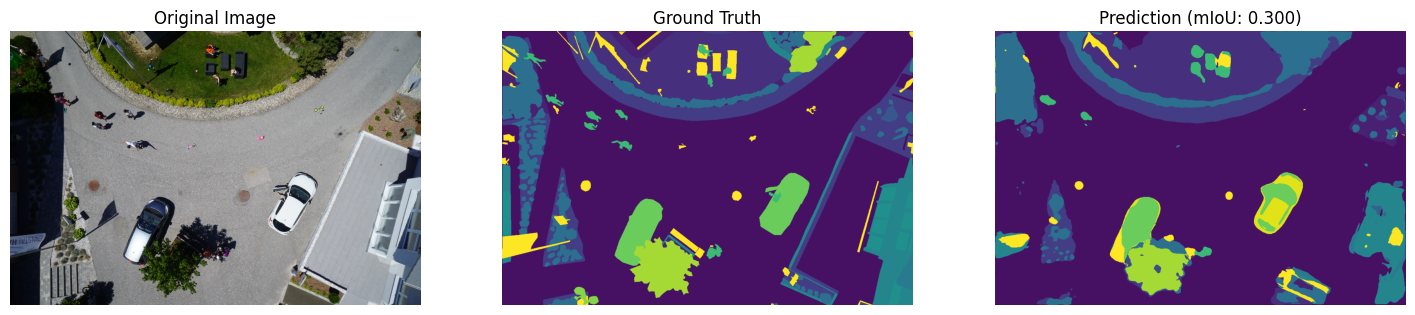

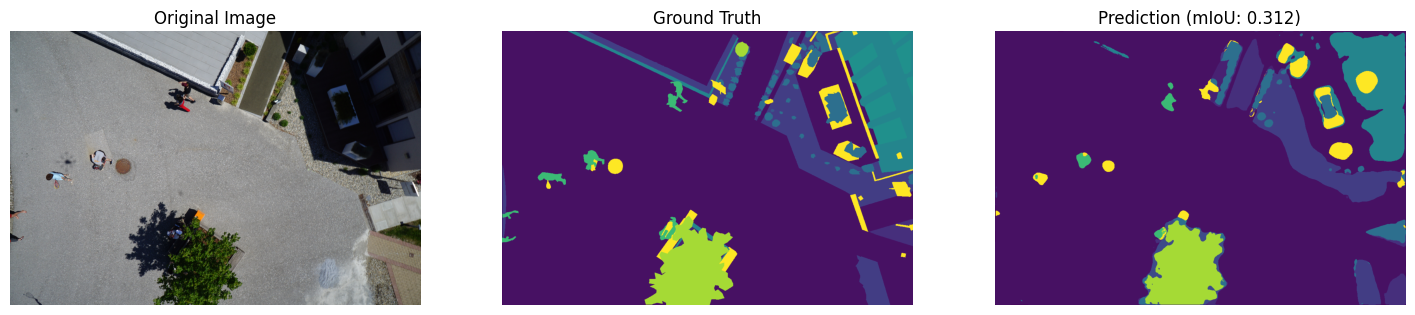

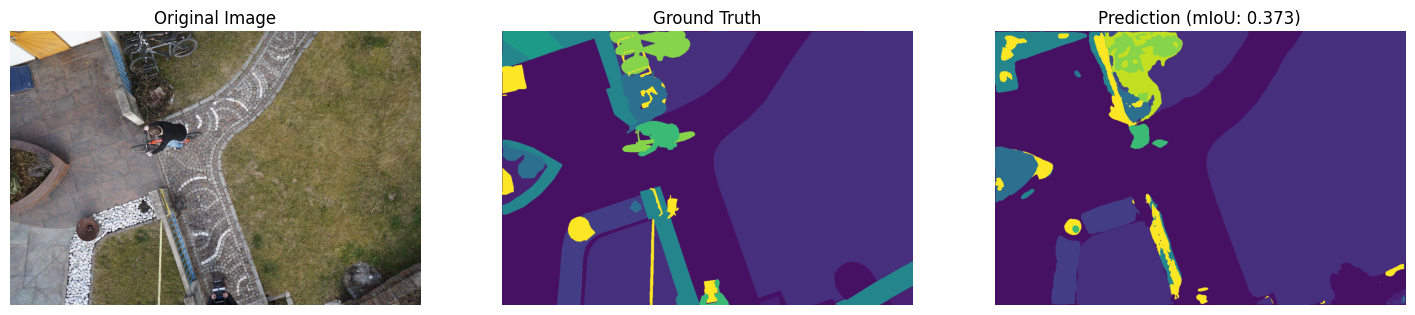

In [25]:
def visualize_predictions(model, test_set, num_samples=3):
    for i in range(num_samples):
        img, mask = test_set[i]
        pred_mask, miou, _ = predict_with_model(model, img, mask)

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

        ax1.imshow(img)
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(mask)
        ax2.set_title('Ground Truth')
        ax2.axis('off')

        ax3.imshow(pred_mask)
        ax3.set_title(f'Prediction (mIoU: {miou:.3f})')
        ax3.axis('off')

        plt.show()

visualize_predictions(model, test_set)

## Test with sample image from the dataset

In [26]:
def test_single_image(model, image_path, mask_path=None, transform=None):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if transform:
        augmented = transform(image=img)
        img = augmented['image']


    img_display = Image.fromarray(img)
    t = T.Compose([T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])])
    img_tensor = t(Image.fromarray(img)).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_display)
    plt.title('Input Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask)
    plt.title('Predicted Segmentation Mask')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


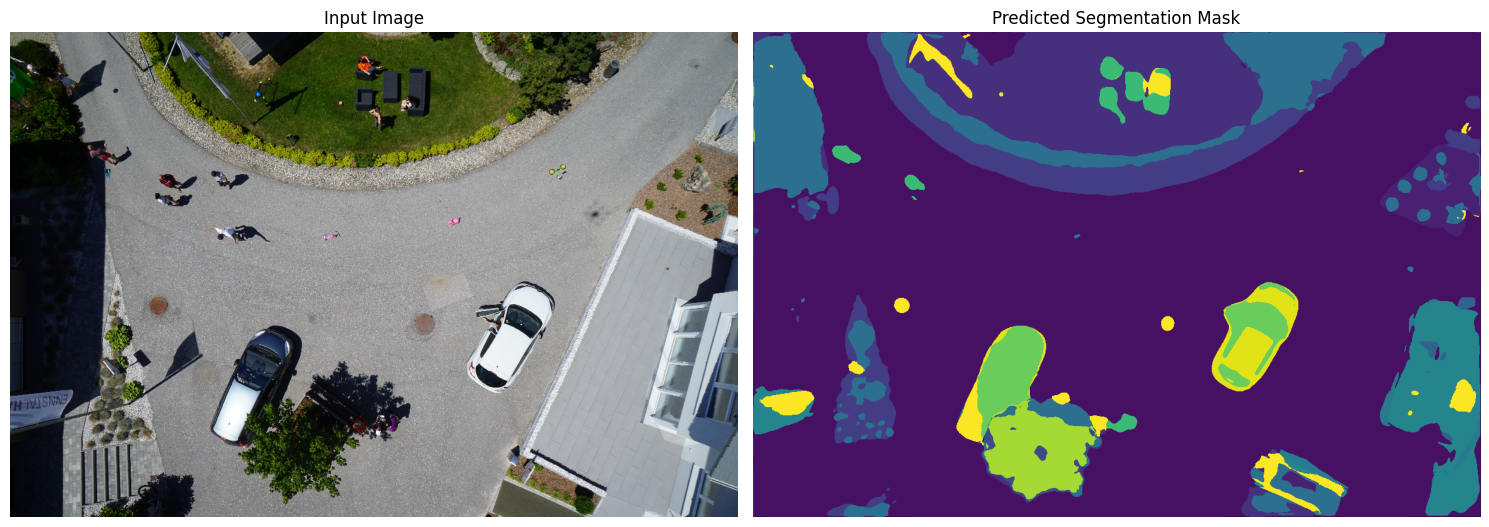

In [30]:
test_image_idx = 0
test_image_path = IMAGE_PATH + X_test[test_image_idx] + '.jpg'
test_single_image(model, test_image_path, transform=test_transform)

## Test with random image by uploading

Saving view.jpg to view (1).jpg


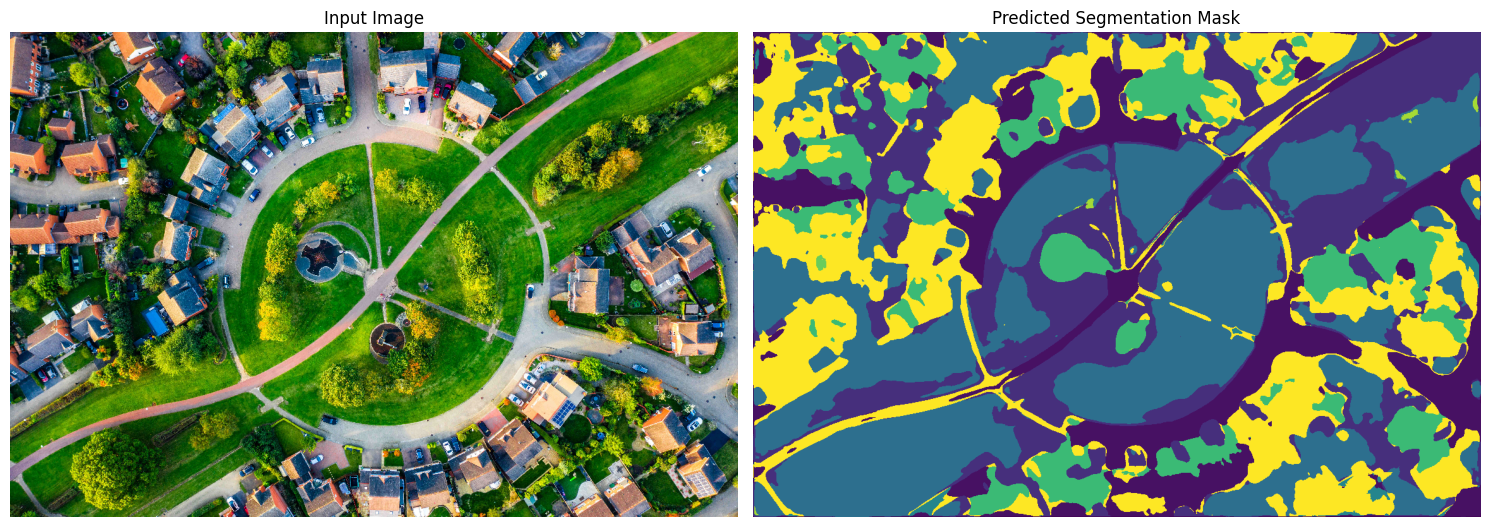

In [31]:
uploaded = files.upload()
custom_image_path = next(iter(uploaded))

custom_transform = A.Resize(768, 1152, interpolation=cv2.INTER_NEAREST)

test_single_image(model, custom_image_path, transform=custom_transform)